In [9]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg

from featuregraph.operators.states import (
    falling_state,
    rising_state,
    positive_state,
    negative_state,
    inactive_state
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [10]:
bidmc = fg.datasets.bidmc(subject=1)
bidmc

,time,respiration,ppg,ecg_v,ecg_avr,ecg_ii,subject
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549,1
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059,1
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980,1
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098,1
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000,1
...,...,...,...,...,...,...,...
59996,479.970,0.15640,0.40567,0.50000,0.51961,0.40000,1
59997,479.980,0.15152,0.40371,0.50588,0.52941,0.39412,1
59998,479.980,0.14663,0.40176,0.50000,0.53529,0.38431,1
59999,479.990,0.14174,0.40176,0.50000,0.53922,0.38039,1


In [11]:
lag = 2
epsilon = 0.001

bidmc['respiration_rising'] = bidmc['respiration'].diff(lag) > epsilon
bidmc['respiration_falling'] = bidmc['respiration'].diff(lag) < -epsilon
bidmc['respiration_inactive'] = bidmc['respiration'].diff(lag).abs() <= epsilon
bidmc['enter_rising'] = bidmc['respiration_rising'].astype(int).diff() == 1
bidmc['exit_rising'] = bidmc['respiration_rising'].astype(int).diff() == -1

(<Figure size 1600x1320 with 6 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_rising'>,
        <Axes: ylabel='respiration_falling'>,
        <Axes: ylabel='respiration_inactive'>,
        <Axes: ylabel='enter_rising'>,
        <Axes: xlabel='Time', ylabel='exit_rising'>], dtype=object))

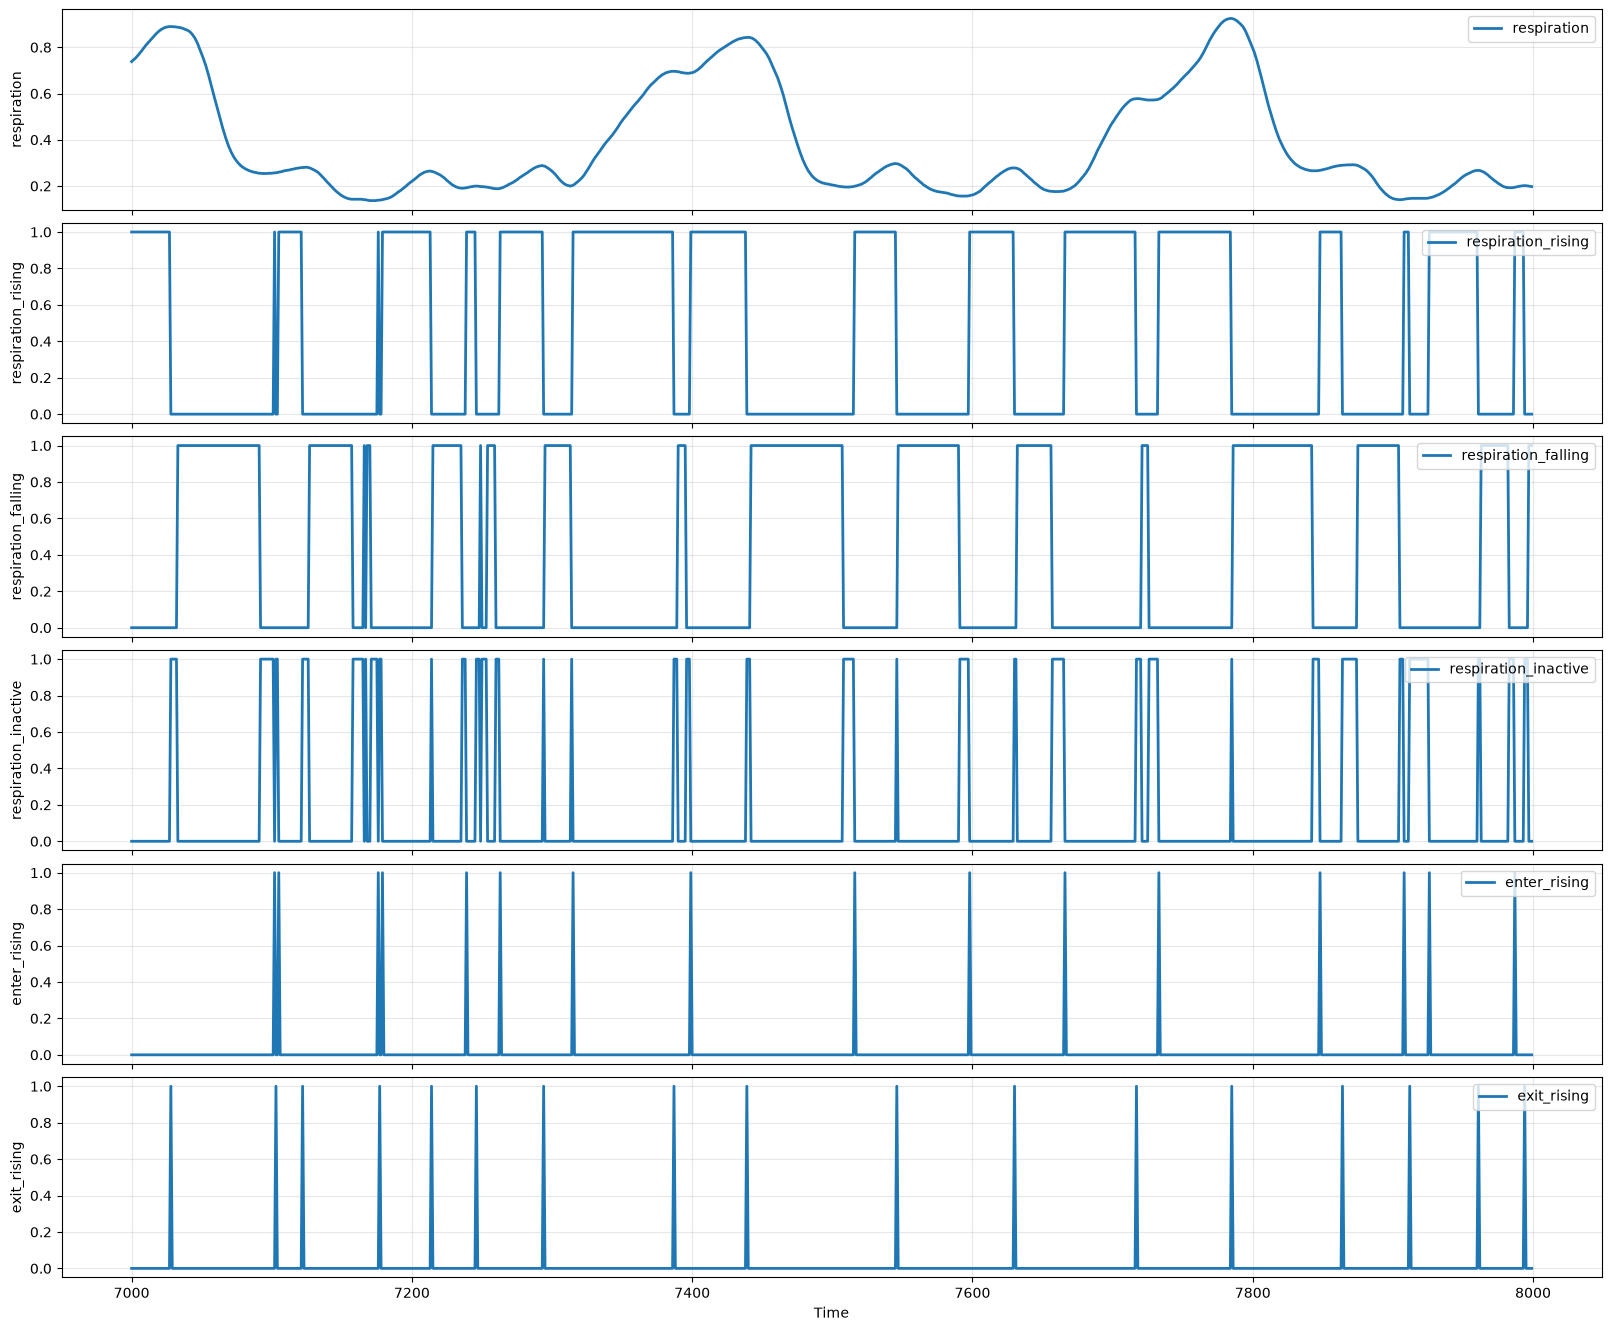

In [12]:
fg.plot(bidmc[7000:8000], [
                            ['respiration'],
                            ['respiration_rising'],
                            ['respiration_falling'],
                            ['respiration_inactive'],
                            ['enter_rising'],
                            ['exit_rising']
                          ])

In [13]:
bidmc_accumulation = fg.accumulation.Accumulation(signals='respiration', group='subject')

In [14]:
bidmc_accumulation

In [15]:
bidmc_transition = fg.transition.Transition(signals='respiration', group='subject')